In [1]:
# Cell 1 — setup
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "stage2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

STAGES = {
    "Stage 2A (MLP)": PROJECT_ROOT / "artifacts" / "stage2",
    "Stage 2B (CNN)": PROJECT_ROOT / "artifacts" / "stage2b",
}

print("Saving charts to:", FIG_DIR)


Saving charts to: /teamspace/studios/this_studio/accessops_coco_ai/reports/figures/stage2



=== Stage 2A (MLP) ===


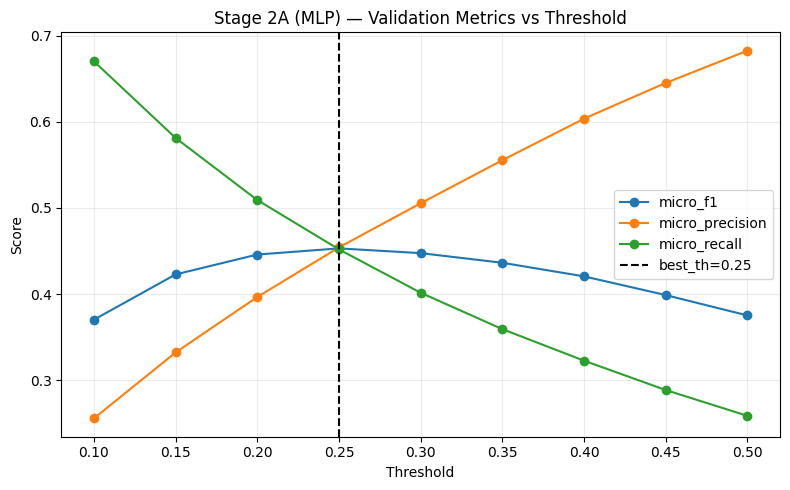

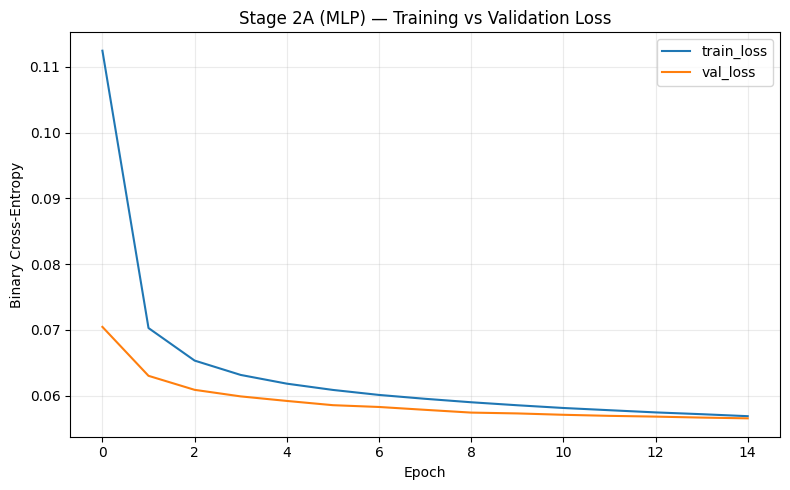

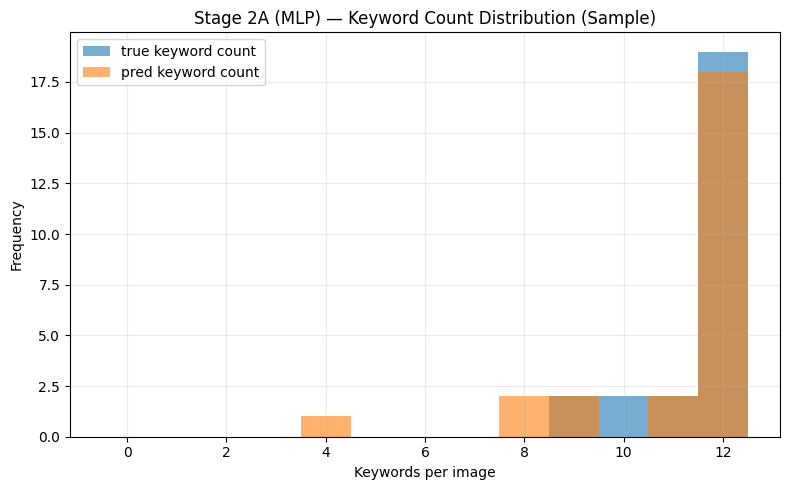

,image_name,true_keywords,pred_keywords_thresholded,pred_top12_by_prob
0,000000289594.jpg,"man, standing, white, street, black, walking, ...","man, standing, people, white, street, person, ...","street, man, black, sidewalk, white, city, wal..."
1,000000289659.jpg,"standing, large, field, walking, grass, area, ...","standing, field, near, grass, looking, area, e...","giraffe, standing, giraffes, field, grass, enc..."
2,000000289702.jpg,"sitting, white, large, black, dog, sits, old, ...","sitting, standing, holding, small, black, dog,...","dog, sitting, black, standing, cat, small, lay..."
3,000000289741.jpg,"people, near, grass, beach, area, view, long, ...","sitting, large, group, near, water, blue, beac...","beach, water, ocean, sand, sitting, near, sand..."
4,000000289938.jpg,"near, dog, food, parked, building, city, road,...","people, street, large, parked, city, road, car...","street, city, large, road, parked, busy, cars,..."
5,000000289960.jpg,"man, standing, person, beach, flying, kite, oc...","man, standing, people, holding, person, water,...","beach, kite, flying, man, person, water, stand..."
6,000000289992.jpg,"white, small, bathroom, sink, wall, orange, sh...","sitting, white, small, room, bathroom, toilet,...","bathroom, toilet, sink, white, shower, mirror,..."
7,000000290081.jpg,"sitting, table, group, blue, wooden, bowl, bun...","sitting, table, wooden, bowl, orange, bananas,...","oranges, bowl, orange, fruit, table, sitting, ..."
8,000000290163.jpg,"standing, plate, red, young, blue, food, girl,...","man, sitting, people, woman, table, holding, p...","table, pizza, sitting, eating, plate, food, ma..."
9,000000290179.jpg,"large, near, clock, city, old, big, view, tall...","people, large, near, train, water, building, c...","water, bridge, city, river, buildings, large, ..."



=== Stage 2B (CNN) ===


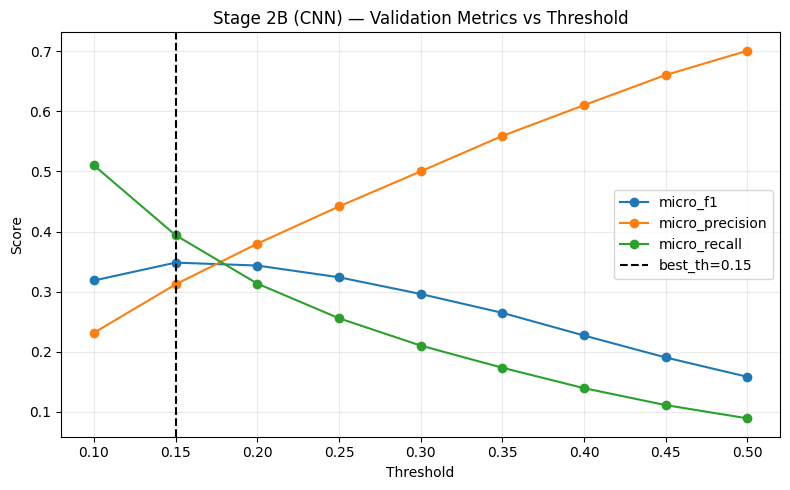

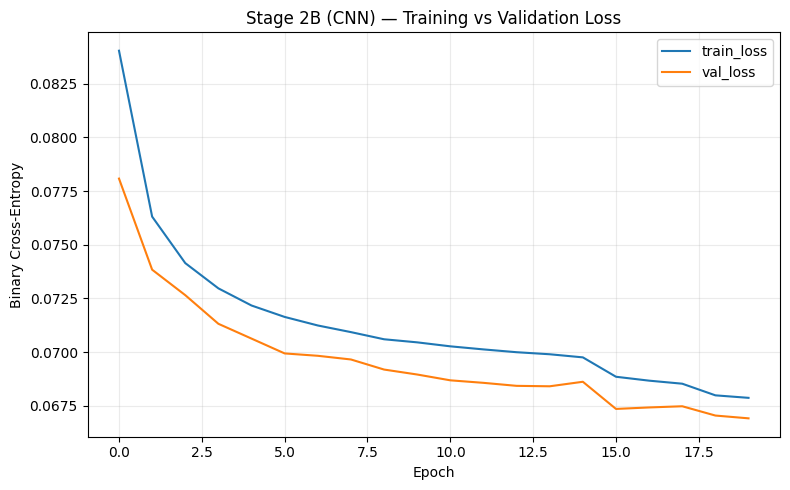

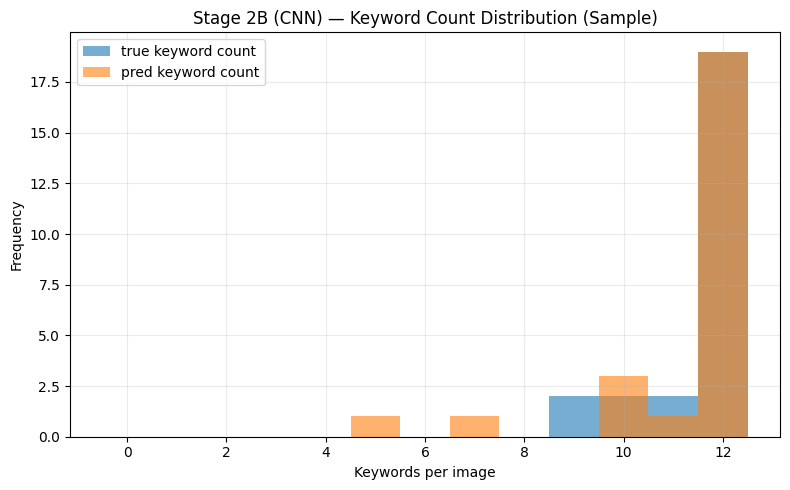

,image_name,true_keywords,pred_keywords_thresholded,pred_top12_by_prob
0,000000289594.jpg,"man, standing, white, street, black, walking, ...","man, sitting, standing, white, street, person,...","black, white, street, sitting, man, parked, tr..."
1,000000289659.jpg,"standing, large, field, walking, grass, area, ...","standing, large, group, field, near, walking, ...","standing, giraffe, field, giraffes, grass, nea..."
2,000000289702.jpg,"sitting, white, large, black, dog, sits, old, ...","man, sitting, standing, white, woman, holding,...","man, sitting, holding, young, woman, standing,..."
3,000000289741.jpg,"people, near, grass, beach, area, view, long, ...","sitting, standing, people, large, group, small...","water, boats, people, large, boat, dock, near,..."
4,000000289938.jpg,"near, dog, food, parked, building, city, road,...","sitting, street, large, near, red, parked, bui...","street, red, sitting, building, city, hydrant,..."
5,000000289960.jpg,"man, standing, person, beach, flying, kite, oc...","man, standing, people, white, holding, person,...","beach, flying, kite, man, ocean, person, water..."
6,000000289992.jpg,"white, small, bathroom, sink, wall, orange, sh...","sitting, white, small, room, bathroom, toilet,...","bathroom, toilet, white, sink, shower, small, ..."
7,000000290081.jpg,"sitting, table, group, blue, wooden, bowl, bun...","sitting, white, table, plate, food, wooden, bo...","sitting, table, plate, bowl, oranges, wooden, ..."
8,000000290163.jpg,"standing, plate, red, young, blue, food, girl,...","man, sitting, standing, woman, table, holding,...","table, food, sitting, man, woman, holding, eat..."
9,000000290179.jpg,"large, near, clock, city, old, big, view, tall...","sitting, standing, white, large, field, small,...","water, near, sitting, large, body, ocean, beac..."


,stage,best_threshold,val_best_micro_f1,test_micro_precision,test_micro_recall,test_micro_f1,test_hamming_loss,test_subset_accuracy
0,Stage 2A (MLP),0.25,0.453033,0.459057,0.457091,0.458072,0.021551,0.0
1,Stage 2B (CNN),0.15,0.348302,0.318235,0.402188,0.355320,0.029081,0.0


Saved: /teamspace/studios/this_studio/accessops_coco_ai/reports/figures/stage2/stage2_metrics_summary.csv


In [2]:
# Cell 2 — per-stage charts (threshold curves, training loss, keyword-count distribution, sample table)
def count_keywords(cell):
    s = str(cell).strip()
    if not s:
        return 0
    return len([x for x in s.split(",") if x.strip()])

summary_rows = []

for stage_name, art_dir in STAGES.items():
    print(f"\n=== {stage_name} ===")
    th_path = art_dir / "threshold_search_val.csv"
    hist_path = art_dir / "training_history.csv"
    sample_path = art_dir / "test_keyword_predictions_sample.csv"
    metrics_path = art_dir / "metrics.json"

    assert th_path.exists(), f"Missing: {th_path}"
    assert hist_path.exists(), f"Missing: {hist_path}"
    assert sample_path.exists(), f"Missing: {sample_path}"
    assert metrics_path.exists(), f"Missing: {metrics_path}"

    th = pd.read_csv(th_path).sort_values("threshold")
    hist = pd.read_csv(hist_path)
    samp = pd.read_csv(sample_path)
    m = json.loads(metrics_path.read_text(encoding="utf-8"))

    best_th = float(m["best_threshold_from_val"])

    # 1) Threshold curves
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(th["threshold"], th["micro_f1"], marker="o", label="micro_f1")
    ax.plot(th["threshold"], th["micro_precision"], marker="o", label="micro_precision")
    ax.plot(th["threshold"], th["micro_recall"], marker="o", label="micro_recall")
    ax.axvline(best_th, linestyle="--", color="black", label=f"best_th={best_th:.2f}")
    ax.set_title(f"{stage_name} — Validation Metrics vs Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{art_dir.name}_threshold_curves.png", dpi=180)
    plt.show()

    # 2) Training curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist["loss"], label="train_loss")
    ax.plot(hist["val_loss"], label="val_loss")
    ax.set_title(f"{stage_name} — Training vs Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Binary Cross-Entropy")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{art_dir.name}_loss_curve.png", dpi=180)
    plt.show()

    # 3) True vs predicted keyword count distribution (from sample csv)
    true_counts = samp["true_keywords"].fillna("").map(count_keywords)
    pred_counts = samp["pred_keywords_thresholded"].fillna("").map(count_keywords)
    bins = np.arange(0, max(true_counts.max(), pred_counts.max()) + 2) - 0.5

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(true_counts, bins=bins, alpha=0.6, label="true keyword count")
    ax.hist(pred_counts, bins=bins, alpha=0.6, label="pred keyword count")
    ax.set_title(f"{stage_name} — Keyword Count Distribution (Sample)")
    ax.set_xlabel("Keywords per image")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{art_dir.name}_keyword_count_hist.png", dpi=180)
    plt.show()

    # Sample table preview
    display(samp.head(10))

    summary_rows.append({
        "stage": stage_name,
        "best_threshold": m["best_threshold_from_val"],
        "val_best_micro_f1": m["val_best_micro_f1"],
        "test_micro_precision": m["test_micro_precision"],
        "test_micro_recall": m["test_micro_recall"],
        "test_micro_f1": m["test_micro_f1"],
        "test_hamming_loss": m["test_hamming_loss"],
        "test_subset_accuracy": m["test_subset_accuracy"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(FIG_DIR / "stage2_metrics_summary.csv", index=False)
display(summary_df)
print("Saved:", FIG_DIR / "stage2_metrics_summary.csv")


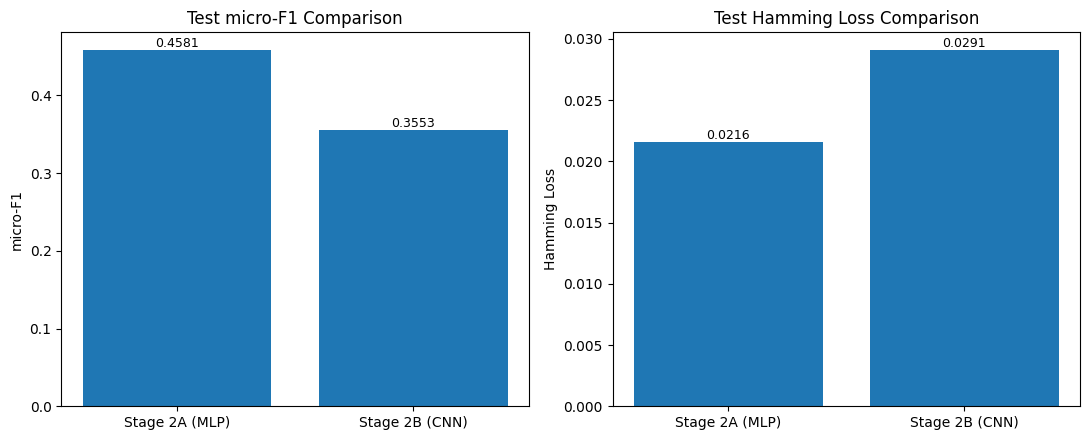

Saved: /teamspace/studios/this_studio/accessops_coco_ai/reports/figures/stage2/stage2a_vs_stage2b_bar_comparison.png
Saved: /teamspace/studios/this_studio/accessops_coco_ai/reports/figures/stage2/stage2a_vs_stage2b_bar_comparison.csv


In [3]:
# Cell 3 — Stage 2A vs Stage 2B comparison bar charts
m2a = json.loads((PROJECT_ROOT / "artifacts" / "stage2" / "metrics.json").read_text(encoding="utf-8"))
m2b = json.loads((PROJECT_ROOT / "artifacts" / "stage2b" / "metrics.json").read_text(encoding="utf-8"))

cmp = pd.DataFrame([
    {"stage": "Stage 2A (MLP)", "test_micro_f1": m2a["test_micro_f1"], "test_hamming_loss": m2a["test_hamming_loss"]},
    {"stage": "Stage 2B (CNN)", "test_micro_f1": m2b["test_micro_f1"], "test_hamming_loss": m2b["test_hamming_loss"]},
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(cmp["stage"], cmp["test_micro_f1"])
axes[0].set_title("Test micro-F1 Comparison")
axes[0].set_ylabel("micro-F1")
for i, v in enumerate(cmp["test_micro_f1"]):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(cmp["stage"], cmp["test_hamming_loss"])
axes[1].set_title("Test Hamming Loss Comparison")
axes[1].set_ylabel("Hamming Loss")
for i, v in enumerate(cmp["test_hamming_loss"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "stage2a_vs_stage2b_bar_comparison.png", dpi=180)
plt.show()

cmp.to_csv(FIG_DIR / "stage2a_vs_stage2b_bar_comparison.csv", index=False)
print("Saved:", FIG_DIR / "stage2a_vs_stage2b_bar_comparison.png")
print("Saved:", FIG_DIR / "stage2a_vs_stage2b_bar_comparison.csv")


In [4]:
# Cell 4 — optional: single "best baseline" statement
best_stage = "Stage 2A (MLP)" if m2a["test_micro_f1"] >= m2b["test_micro_f1"] else "Stage 2B (CNN)"
print("Best Stage-2 baseline by test micro-F1:", best_stage)
print("Stage 2A micro-F1:", round(m2a["test_micro_f1"], 4))
print("Stage 2B micro-F1:", round(m2b["test_micro_f1"], 4))


Best Stage-2 baseline by test micro-F1: Stage 2A (MLP)
Stage 2A micro-F1: 0.4581
Stage 2B micro-F1: 0.3553
